# **Necessary Imports**

In [ ]:
!pip install keras_tuner

In [ ]:
# Numerical arrays
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Neural network
import tensorflow as tf
import keras
from google.colab import drive
from sklearn.model_selection import train_test_split

# Data Preprocessing
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, mutual_info_classif

# Model evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, precision_recall_curve, auc
import sklearn

# Model optimization
from tensorflow.keras import regularizers
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

# Hyperparameter tuning
from keras_tuner import RandomSearch

sklearn.set_config(display='diagram')
drive.mount('/content/drive')

# Hide warnings
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer-telco-churn/data/cleaned/cleaned_data.csv')

# **Data Preprocessing**

In [ ]:
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Remove highly correlated features
corr_matrix = df.corr(numeric_only=True)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
correlations = df.corr(numeric_only=True)['Churn']

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
  for j in range(i):
    if abs(corr_matrix.iloc[i, j]) > 0.8:
      high_corr_pairs.append((
          corr_matrix.columns[i],
          corr_matrix.columns[j],
          corr_matrix.iloc[i, j]
      ))
high_corr_pairs

[('TotalCharges', 'tenure', np.float64(0.8261642132368037))]

In [ ]:
# Remove one feature
to_remove = []

for f1, f2, corr_value in high_corr_pairs:
  # compare target correlation
  if abs(correlations[f1]) > abs(correlations[f2]):
    to_remove.append(f2)
  else:
    to_remove.append(f1)

to_remove = list(set(to_remove))
print(to_remove)

['TotalCharges']


In [ ]:
df = df.drop(columns=to_remove)

In [ ]:
# Remove features that have low correlation with the target
corr_threshold = 0.05

low_corr_features = correlations[abs(correlations) < corr_threshold].index
print("Remove these:", list(low_corr_features))

Remove these: ['Unnamed: 0']


In [ ]:
# Drop the column
df = df.drop(columns=low_corr_features)

In [ ]:
# Categorical
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include='number').columns

X_encoded = pd.get_dummies(X, drop_first=True)

mi = mutual_info_classif(X_encoded, y)
mi_scores = pd.Series(mi, index=X_encoded.columns).sort_values()
print(mi_scores)

gender_Male                              0.000000
MultipleLines_No phone service           0.000000
PaymentMethod_Mailed check               0.000000
MultipleLines_Yes                        0.001464
OnlineBackup_Yes                         0.001539
DeviceProtection_Yes                     0.003545
StreamingTV_Yes                          0.003649
StreamingMovies_Yes                      0.005040
PaymentMethod_Credit card (automatic)    0.005125
PhoneService_Yes                         0.006463
Dependents_Yes                           0.008567
TechSupport_Yes                          0.009944
SeniorCitizen                            0.011891
Partner_Yes                              0.012103
OnlineSecurity_Yes                       0.014802
Contract_One year                        0.017230
PaperlessBilling_Yes                     0.017247
OnlineSecurity_No internet service       0.025443
InternetService_No                       0.029216
OnlineBackup_No internet service         0.029545


In [ ]:
low_mi_features = mi_scores[mi_scores <= 0.01].index.to_list()
print("Remove these:", low_mi_features)

Remove these: ['gender_Male', 'MultipleLines_No phone service', 'PaymentMethod_Mailed check', 'MultipleLines_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'PaymentMethod_Credit card (automatic)', 'PhoneService_Yes', 'Dependents_Yes', 'TechSupport_Yes']


In [ ]:
X_selected = X_encoded.drop(columns=low_mi_features)
print("Initial shape:", X_encoded.shape)
print("Final shape:", X_selected.shape)

Initial shape: (7043, 29)
Final shape: (7043, 17)


In [ ]:
# Append each feature by their type
binary_cols = []
numerical_cols = []
ordinal_cols = []
multinomial_cols = []

for col in df.columns:
  if col == 'Churn' or col == 'customerID':
    continue

  unique_vals = df[col].nunique()
  if df[col].dtype == 'object':
    if unique_vals == 2:
      print(f"{col}: Binary")
      binary_cols.append(col)
    elif col == 'Contract':
      ordinal_cols.append(col)
      print(f"{col}: Ordinal")
    else:
      multinomial_cols.append(col)
      print(f"{col}: Multinomial")
  else:
    numerical_cols.append(col)
    print(f"{col}: Numerical")

# categorical_columns = X.select_dtypes(include='object').columns
# numerical_columns = X.select_dtypes(include=np.number).columns

Unnamed: 0: Numerical
gender: Binary
SeniorCitizen: Numerical
Partner: Binary
Dependents: Binary
tenure: Numerical
PhoneService: Binary
MultipleLines: Multinomial
InternetService: Multinomial
OnlineSecurity: Multinomial
OnlineBackup: Multinomial
DeviceProtection: Multinomial
TechSupport: Multinomial
StreamingTV: Multinomial
StreamingMovies: Multinomial
Contract: Ordinal
PaperlessBilling: Binary
PaymentMethod: Multinomial
MonthlyCharges: Numerical
TotalCharges: Numerical


## **Applying Column Transformer**

In [ ]:
def preprocess_data(df):
  if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

  df.dropna(inplace=True)
  df.drop('customerID', inplace=True)

  binary_cols = []
  numerical_cols = []
  ordinal_cols = []
  multinomial_cols = []

  for col in df.columns:
    if col == 'Churn' or col == 'customerID':
      continue

    unique_vals = df[col].nunique()
    if df[col].dtype == 'object':
      if unique_vals == 2:
        print(f"{col}: Binary")
        binary_cols.append(col)
      elif col == 'Contract':
        ordinal_cols.append(col)
        print(f"{col}: Ordinal")
      else:
        multinomial_cols.append(col)
        print(f"{col}: Multinomial")
    else:
      numerical_cols.append(col)
      print(f"{col}: Numerical")

  ordinal_categories = [[
      'Month-to-month',
      'One year',
      'Two year'
  ]]

  preprocessor = ColumnTransformer(
      transformers=[
          ('binary', OrdinalEncoder(), binary_cols),  #
          ('ordinal', OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
          ('nominal', OneHotEncoder(drop='first', sparse_output=False), multinomial_cols),  # Produce a numpy array and avoid dummy trap variable
          ('numeric', Pipeline([
              ('imputer', SimpleImputer(strategy='median')),
              ('scaler', StandardScaler())
          ]), numerical_cols)
      ]
  )
  return df, preprocessor

In [ ]:
df, preprocessor = preprocess_data(df)

X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

KeyError: "['customerID'] not found in axis"

# **Model Training**

## **Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
# Apply one hot encoding to nominal features
ohe = preprocessor.named_transformers_['nominal']
ohe_cols = ohe.get_feature_names_out(multinomial_cols)

# Combine all processed column names
processed_columns = binary_cols + ordinal_cols + list(ohe_cols) + numerical_cols

# Apply smote to handle class imbalance
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)
X_train_balanced = pd.DataFrame(X_train_balanced, columns=processed_columns)
y_train_balanced = pd.Series(y_train_balanced)

In [ ]:
categorical_cols = [col for col in X_train_balanced.columns if col not in numerical_cols]
X_cat = X_train_balanced[categorical_cols]
X_num = X_train_balanced[numerical_cols]
chi2_selector = SelectKBest(chi2, k=15)
chi2_selector.fit(X_cat, y_train_balanced)

SelectKBest(k=15, score_func=<function chi2 at 0x78cf2ce544a0>)

In [ ]:
# Get  boolean mask of top features
mask = chi2_selector.get_support()

# List of selected categorical features
selected = X_cat.columns[mask]
print("Selected features:", list(selected))

# Reduce X cat to only selected columns
X_cat_selected = X_cat[selected]

# Combine with numeric features
X_train_selected = pd.concat([X_cat_selected, X_num], axis=1)

# Repeat for X test for testing
cat_indices = [processed_columns.index(col) for col in selected] # Only top 15 categorical
num_indices = [processed_columns.index(col) for col in numerical_cols] # numerical columns

X_test_cat_selected = X_test_processed[:, cat_indices]
X_test_num_selected = X_test_processed[:, num_indices]

# Combine categorical and numerical
X_test_selected = np.hstack([X_test_cat_selected, X_test_num_selected])

print(X_train_selected.shape)
print(X_test_selected.shape)

Selected features: ['Dependents', 'PaperlessBilling', 'Contract', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check']
(8276, 20)
(1409, 20)


In [ ]:
def build_nn(input_dim):
  """
  Builds a neural network for churn prediction
  """

  model = keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim, )),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    # Output layer
    tf.keras.layers.Dense(1, activation='sigmoid')
  ])
  return model
model = build_nn(X_train_selected.shape[1])

In [ ]:
# Get model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Compile the model
def compile_model(model, learning_rate=0.001):   # default value for learning rate
  optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
  metrics = [
      keras.metrics.BinaryAccuracy(name='accuracy'),   # predicted probs >= 0.5 then class 1
      keras.metrics.Precision(name='precision'),
      keras.metrics.Recall(name='recall'),
      keras.metrics.AUC(name='auc'),  # seperates positive and negative classes across all probability thresholds
      keras.metrics.AUC(name='prc', curve='PR') # Precision recall AUC (heavily focuses on positive class behaviour and performance under imbalance)
  ]

  model.compile(
      optimizer = optimizer,
      loss = 'binary_crossentropy',
      metrics = metrics
  )
  return model

model = compile_model(model, learning_rate=0.001)

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_balanced),
    y=y_train_balanced
)

class_weight_dict = dict(zip(np.unique(y_train_balanced), class_weights))
print(class_weight_dict)

{np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


In [ ]:
callbacks = [
      tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,  # stop is val loss does not improve in 15 epochs
        mode='min', # lower loss is better
        restore_best_weights=True,
        verbose=1
      )
  ]
history = model.fit(
      X_train_selected,
      y_train_balanced,
      batch_size=64,
      epochs=50,
      validation_data=(X_test_selected, y_test),
      callbacks=callbacks,
      class_weight=class_weight_dict
)

Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.6598 - auc: 0.7197 - loss: 0.7567 - prc: 0.7024 - precision: 0.6586 - recall: 0.6798 - val_accuracy: 0.6955 - val_auc: 0.8562 - val_loss: 0.6569 - val_prc: 0.6652 - val_precision: 0.4615 - val_recall: 0.9008
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7386 - auc: 0.8132 - loss: 0.6178 - prc: 0.7824 - precision: 0.7276 - recall: 0.7545 - val_accuracy: 0.7012 - val_auc: 0.8542 - val_loss: 0.6276 - val_prc: 0.6615 - val_precision: 0.4669 - val_recall: 0.9088
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7425 - auc: 0.8172 - loss: 0.6058 - prc: 0.7858 - precision: 0.7244 - recall: 0.7809 - val_accuracy: 0.7182 - val_auc: 0.8581 - val_loss: 0.5979 - val_prc: 0.6756 - val_precision: 0.4826 - val_recall: 0.8901
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7517 - auc: 0.8221 - loss: 0.5900 - prc: 0.7877 - precision: 0.7330 - recall: 0.7949 - val_accuracy: 0.7523 

## **Class Weights**

In [ ]:
mi_scores = mutual_info_classif(X_train_selected, y_train_balanced, discrete_features='auto', random_state=42)
mi_scores = pd.Series(mi_scores, index=X_train_selected.columns).sort_values(ascending=False)
print(mi_scores)

tenure                                   0.296116
Contract                                 0.158820
MonthlyCharges                           0.104480
PaymentMethod_Electronic check           0.085782
PaperlessBilling                         0.068073
InternetService_Fiber optic              0.062410
Dependents                               0.056574
OnlineSecurity_Yes                       0.051377
TotalCharges                             0.050682
TechSupport_Yes                          0.050428
StreamingMovies_No internet service      0.043291
PaymentMethod_Credit card (automatic)    0.041912
OnlineSecurity_No internet service       0.041565
OnlineBackup_No internet service         0.041340
StreamingTV_No internet service          0.040494
TechSupport_No internet service          0.040239
DeviceProtection_No internet service     0.036295
InternetService_No                       0.035291
SeniorCitizen                            0.013507
Unnamed: 0                               0.000000


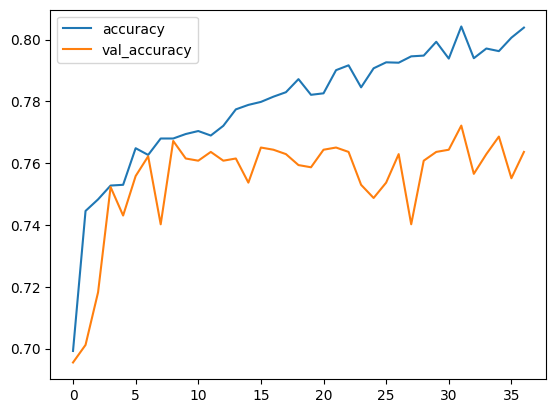

In [ ]:
# Plot accuracy and validation accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

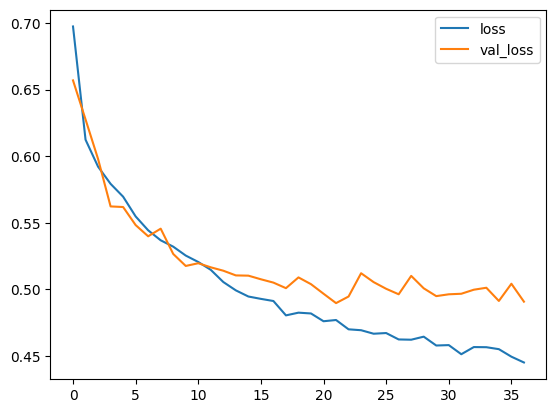

In [ ]:
# Plot loss and validation loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the neural network
print(model.evaluate(X_test_selected, y_test))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7780 - auc: 0.8625 - loss: 0.4772 - prc: 0.6944 - precision: 0.5713 - recall: 0.7930
[0.4896065294742584, 0.7650816440582275, 0.5373665690422058, 0.8096514940261841, 0.8551385402679443, 0.6806635856628418]


In [ ]:
predictions = model.predict(X_test)
cm = confusion_matrix(y_test, predictions.round())
cm

ValueError: Invalid dtype: object

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# **Hyperparameter Tuning**

In [ ]:
input_dim = X_train_selected.shape[1]

def build_model(hp):
  global input_dim
  model = keras.Sequential()
  model.add(tf.keras.layers.Input(shape=(input_dim, ))) # input_dim for number of features

  # Tune number of layers
  for i in range(hp.Int('num_layers', 1, 4)): # try 1 to 4 hidden layers (different amounts may be underfitting/overfitting)
    model.add(tf.keras.layers.Dense(
        units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),

        # relu to prevent vanising gradients and suited for hidden layers
        activation='relu',

        # Prevent overfitting
        kernel_regularizer=regularizers.l2(hp.Float('l2', 1e-5, 1e-1, sampling='log'))
    ))
    model.add(tf.keras.layers.Dropout(hp.Float('dropout', 0.1, 0.5, step=0.1)))

    # Normalize output of previous layers
    model.add(tf.keras.layers.BatchNormalization())

  model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

  model.compile(

                # Tune learning rate with log values
      optimizer=tf.keras.optimizers.Adam(
          learning_rate=hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
      ),
      loss='binary_crossentropy', # for binrary classification
      metrics=['accuracy', tf.keras.metrics.AUC(name='auc')] # better for imbalancd data than accuracy
  )
  return model

In [ ]:
# Run hyperparameter search
tuner = RandomSearch(
    build_model,
    objective='val_auc',
    max_trials=10,
    executions_per_trial=2,
    directory='tuner_results'
)

Reloading Tuner from tuner_results/untitled_project/tuner0.json


In [ ]:
tuner.search(
    X_train_selected,
    y_train_balanced,
    epochs=30,
    validation_data=(X_test_selected, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)]
)

Trial 2 Complete [00h 00m 49s]
val_auc: 0.8592616319656372

Best val_auc So Far: 0.8612930774688721
Total elapsed time: 00h 02m 50s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
1                 |4                 |num_layers
256               |64                |units_0
1.8809e-05        |0.0029669         |l2
0.3               |0.3               |dropout
0.006287          |0.0004946         |learning_rate
192               |32                |units_1
32                |32                |units_2
64                |32                |units_3

Epoch 1/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7296 - auc: 0.8014 - loss: 0.5748 - val_accuracy: 0.7814 - val_auc: 0.8522 - val_loss: 0.4685
Epoch 2/30
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7590 - auc: 0.8333 - loss: 0.5065 - val_accuracy: 0.7296 - val_auc: 0.8530 - val_loss: 0.5327
Epoch 3/30
143/259 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7584 - auc: 0.8367 - loss: 0.

KeyboardInterrupt: 

KeyError: 'Churn'